# Retail Sarthi Agent powered by Sarvam-M model and QWEN 3.5 4B

In this notebook we will be implementing an agent architecture for a platform that helps kirana shops and small scale businesses get suggestions on inventory management to prevent "Inventory Overhang".This is a part of our final year project as team 46 from CMR University

Our goals : 
- To create a smart agent that understand user query from audio or text format. (ASR and Model)
- Use Agentic RAG so that the agent uses relavent information on its own.
- Call relavent tools for demand forecasting, trends prediction, Inventory Check from DB. 
- Provide simple to understand output to the user. 

In [1]:
#import all libraries

import os 
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI
from langchain_ollama import ChatOllama

from langgraph.graph import START,StateGraph,MessagesState,END
from langchain_core.messages import SystemMessage,HumanMessage,AIMessage
from typing import Optional
import json
from typing import Literal,TypedDict
from supabase import create_client, Client  
from langgraph.prebuilt import ToolNode,tools_condition
from IPython.display import Image, display
from langchain_core.tools import tool
import re

c:\Users\adhis\OneDrive\Desktop\RS-SLM-Agent\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Load environment variables from .env file and setup LLMS and Supabase client

load_dotenv()

SARVAM_API_KEY = os.getenv("Sarvam-API")

# Initialize the Sarvam LLM 
convo_llm = ChatOpenAI(model ="sarvam-m",
                 api_key=SARVAM_API_KEY,
                 base_url="https://api.sarvam.ai/v1",
                 )

#Initialize the Ollama LLM for tool calls
tool_llm = ChatOllama(model="qwen3.5:4b")

#Establish connection to Supabase
SUPABASE_URL = os.getenv("SUPABASE_URL")
SUPABASE_KEY = os.getenv("SUPABASE_KEY")

supabase : Client = create_client(SUPABASE_URL, SUPABASE_KEY)

In [3]:
class Graph_State(MessagesState):
    Query:Optional[str]
    Intent:Optional[list[str]]
    language:Literal["English","Hindi","Kannada","Telugu"]
    needs_tool:Optional[bool]
    tool_agent_response:Optional[str]

In [4]:
sys_prompt ="""
Your name is "Retail Saarthi".Your role is to converse naturally with the shop owner, understand their core need, and translate their request for our backend systems.The Languages you support are Hindi,English,Telugu and Kannada . If user sends a message of any language in english text identify the language and respond in the same language and script. For example : "Meru Yevaru,koncham chepandi?" is in Telugu language and script so you should respond in Telugu language and script.

    Whenever you introduce yourself or respond to a general greeting, you MUST define yourself by saying: "I am your smart helper to manage your inventory stock to prevent inventory overhang." You MUST also mention that you were "developed by Adhish Bharadwaj, Chaitanya Kumar Arya, and Sree Harshitha Tadepalli, with Dr. K.P. Aggarwal as the mentor for our final year project." Always maintain a polite, helpful, and culturally appropriate tone.

    CRITICAL INSTRUCTION: You must output ONLY a raw, valid JSON object. Do not include markdown tags (like ```json), and do not include any conversational text before or after the JSON.
    
    Analyze the conversation history and the user's latest message. You must output your response EXACTLY as a valid JSON object. Do not include any conversational filler before or after the JSON block. 

    Your JSON output must follow this exact structure:

    {
      "intent": "Determine the user's goal. Use ONLY one of these exact phrases: 'General Chat', 'Inventory Help', 'Demand Forecasting', or 'Policy Question'.",
      "needs_tool_call": "true or false. (Set to false if the intent is 'General Chat'. Set to true for 'Inventory Help', 'Demand Forecasting', or 'Policy Question').This will be a Boolean value only, not a string.",
      "english_query": "Translate the user's latest query into clear, actionable English so the backend tool-caller can understand exactly what needs to be calculated or searched. If the intent is 'General Chat', write 'N/A'.",
      "chat_response": "If the intent is 'General Chat', write your full, helpful reply here in the exact language and script the user spoke. If the intent requires backend data, write a brief, polite acknowledgement in the user's language and script here (e.g., 'Let me check the stock for you...', 'जी, मैं अभी चेक करता हूँ...', etc.)."
      "Language": "Identify the language of the user's query. Use ONLY one of these exact phrases: 'English', 'Hindi', 'Kannada', or 'Telugu'."
    }
"""


def Intent(state:Graph_State):
    user_message=state["messages"][-1]
    response = convo_llm.invoke([SystemMessage(content=sys_prompt),user_message])

    try:
        clean_text = re.sub(r'<think>\s*', '', response.content)
        clean_text = re.sub(r'</think>\s*', '', clean_text)
        clean_text = clean_text.strip("` \n").replace("json\n", "")
        parsed_response = json.loads(clean_text)

        intent = parsed_response.get("intent")
        user_query = parsed_response.get("english_query")
        needs_tools = parsed_response.get("needs_tool_call")
        language = parsed_response.get("Language")
        chat_response = parsed_response.get("chat_response")

        return{
            "Query": user_query,
            "Intent":intent,
            "needs_tool": needs_tools,
            "messages":[AIMessage(content=chat_response)],
            "language": language
        }
    except json.JSONDecodeError:
        print(f"Failed to parse JSON. Raw response was: {response.content}")
        error_message = "Sorry, I had trouble understanding your request. Could you please rephrase it?"
        return {
            "Intent": "Error",
            "needs_tool": False,
            "messages": [AIMessage(content=error_message)]
        }


In [5]:
'''
@tool 
def inventory_check_tool(product_name:str)->str:
    """
    Checks the current inventory levels and overhang status for a specific product.
    Call this tool when the user asks about stock, availability, or inventory overhang.
    STRICTLY FOLLLOW : Do not call this tool more than 3 times for one query.

    Args:
    product_name : str   The name of the product to check inventory for (e.g., "Parle-G", "Mustard Oil", etc.)

    """

    search_term = product_name.strip().lower()

    try : 
        response = supabase.table("mock_inventory")\
            .select("quantity, overhang_status, last_restocked")\
            .ilike("product_name", f"%{search_term}%") \
            .execute()
        
        data = response.data

        if data :
            item = data[0]  # Assuming the first match is the most relevant
            answer = f"Found {product_name}: {item['quantity']} units in stock."
            return {
                "messages": [answer]
            }
        else:
            return f"Product '{product_name}' not found in the Supabase database."
    except Exception as e:
        return f"Database error while checking inventory: {str(e)}"
    


'''

'\n@tool \ndef inventory_check_tool(product_name:str)->str:\n    """\n    Checks the current inventory levels and overhang status for a specific product.\n    Call this tool when the user asks about stock, availability, or inventory overhang.\n    STRICTLY FOLLLOW : Do not call this tool more than 3 times for one query.\n\n    Args:\n    product_name : str   The name of the product to check inventory for (e.g., "Parle-G", "Mustard Oil", etc.)\n\n    """\n\n    search_term = product_name.strip().lower()\n\n    try : \n        response = supabase.table("mock_inventory")            .select("quantity, overhang_status, last_restocked")            .ilike("product_name", f"%{search_term}%")             .execute()\n\n        data = response.data\n\n        if data :\n            item = data[0]  # Assuming the first match is the most relevant\n            answer = f"Found {product_name}: {item[\'quantity\']} units in stock."\n            return {\n                "messages": [answer]\n         

In [7]:
# Mock Demand function that mimics demand forecast output from model

from datetime import datetime
from typing_extensions import TypedDict

class mock_df_input(TypedDict):
    product_name:str
    date:str

class mock_df_output(TypedDict):
    product_name: str
    Predicted_Demand: str
    Upper_Bound: str
    Recommended_Price: float
    Stock_Suggestion:int
    Is_Weekend:bool       
    Has_Event:bool       
    Slow_Mover:bool        


#Mock
@tool
def demand_forecast_tool(input: mock_df_input) -> mock_df_output:
    """
    Demand forecasting tool for testing end-to-end agent flow.

    Instructions:
    - Use this tool only for demand forecasting requests.
    - Pass both product_name and date in the input payload.
    - date must be in YYYY-MM-DD format.
    - Call this tool only once per user query.
    - Do not alter product_name; pass the extracted value as-is.

    Args:
        input (mock_df_input): Input payload for forecast simulation.
            product_name (str): Product name to forecast demand for.
            date (str): Forecast date in YYYY-MM-DD format.

    Returns:
        mock_df_output: Mock forecast response containing demand, upper bound,
        recommended price, stock suggestion, and control flags.
    """
    payload = input or {}
    product_name = str(payload.get("product_name", "Unknown Product")).strip() or "Unknown Product"
    date_str = str(payload.get("date", "")).strip()

    is_weekend = False
    if date_str:
        try:
            parsed_date = datetime.strptime(date_str, "%Y-%m-%d")
            is_weekend = parsed_date.weekday() >= 5
        except ValueError:
            # Keep default False when date format is invalid.
            is_weekend = False

    predicted_units = 80 if is_weekend else 60
    upper_bound_units = predicted_units + 20
    recommended_price = 49.0
    stock_suggestion = upper_bound_units + 10

    return {
        "product_name": product_name,
        "Predicted_Demand": f"{predicted_units} units",
        "Upper_Bound": f"{upper_bound_units} units",
        "Recommended_Price": recommended_price,
        "Stock_Suggestion": stock_suggestion,
        "Is_Weekend": is_weekend,
        "Has_Event": False,
        "Slow_Mover": predicted_units < 70,
    }

# Trend Tool

@tool 
def trend_search(query:str)->str:
    """
    Mock trend search tool to simulate searching for current market trends related to a product or category.

    Instructions:
    - Use this tool when the user asks about current trends, popular products, or market insights.
    - Pass a clear and concise query that specifies the product or trend topic (e.g., "current trends in biscuits", "popular cooking oils", etc.).
    - Call this tool only once per user query.

    Args:
        query (str): The search query specifying the trend information needed.

    Returns:
        str: A mock response containing trend information.
    """
    # This is a simple mock implementation - replace with actual trend search logic
    return f"Here are the latest trends for '{query}': [Trend 1, Trend 2, Trend 3]"

In [8]:
tools =[demand_forecast_tool,trend_search]

llm_with_tools = tool_llm.bind_tools(tools)

In [9]:
tool_node = ToolNode(tools) #Execute tool calls 

tool_agent_sys_prompt = """
You are "Retail Saarthi Tool Agent", a backend assistant that executes tools based on user intent.

**Your Role:**
1. Analyze the user's query and select the most appropriate tool
2. Extract required parameters exactly from the query
3. Call the selected tool with the right input format
4. Summarize tool results in a clear, helpful response

**Available Tools:**

1. **demand_forecast_tool**
- Purpose: Generate a mock demand forecast for a product on a specific date
- Required Input: `input` object with
  - `product_name` (str)
  - `date` (str in YYYY-MM-DD format)
- When to use: User asks for demand prediction, expected sales, future demand, or stocking guidance for a date

2. **trend_search**
- Purpose: Return mock market trend insights for a product/category
- Required Parameter: `query` (str)
- When to use: User asks about market trends, popular items, seasonal demand, or category performance

**Rules:**
- Always use the English query provided by upstream intent processing
- Do not hallucinate product names, dates, or trend topics
- Call only one tool per query unless the user explicitly asks for both forecast and trends
- After receiving tool results, provide a final summary and do not call tools again
- ALWAYS respond in ENGLISH only
"""

def Tool_agent(state: Graph_State):
    query = state["Query"]  # English query
    messages = state["messages"]
    
    last_message = messages[-1] if messages else None
    
    if last_message and hasattr(last_message, 'type') and last_message.type == "tool":
        # Only include tool-related messages (AIMessage with tool_calls + ToolMessage)
        # Filter out the Kannada/Hindi chat messages
        tool_messages = []
        for msg in messages:
            # Include AIMessage only if it has tool_calls
            if hasattr(msg, 'tool_calls') and msg.tool_calls:
                tool_messages.append(msg)
            # Include ToolMessage (tool results)
            elif hasattr(msg, 'type') and msg.type == "tool":
                tool_messages.append(msg)
        
        llm_messages = [
            SystemMessage(content=tool_agent_sys_prompt),
            HumanMessage(content=query)  # Always use English query
        ] + tool_messages
    else:
        # First call - just use the English query
        llm_messages = [
            SystemMessage(content=tool_agent_sys_prompt),
            HumanMessage(content=query)
        ]
    
    response = llm_with_tools.invoke(llm_messages)
    result = {"messages": [response]}
    
    # Store English response when no more tool calls
    if not response.tool_calls:
        result["tool_agent_response"] = response.content
    
    return result

#TODO Can improve this by checking if the response is already in english and only translating if it's not, instead of always calling the LLM for translation. 
# This would save costs and latency for general chat queries that are already in the correct language.
def Final_Response(state: Graph_State):
    tool_response = state['tool_agent_response']
    language = state['language']
    
    final_prompt = f"""
    Convert the following English response into {language} language and script.
    Keep it natural, friendly and suitable for a retail shop owner.
    
    
    Output ONLY the translated response, nothing else.
    """
    
    response = convo_llm.invoke([SystemMessage(content=final_prompt),tool_response])
    clean_text = re.sub(r'<think>\s*', '', response.content)
    
    return {"messages": [AIMessage(content=clean_text)]}

In [10]:
def intent_route(state:Graph_State)->Literal["tool_agent",END]:
    if state['needs_tool']:
        return "tool_agent"
    else:
        return END
    
def tool_agent_route(state: Graph_State) -> Literal["tools", "final_response"]:
    """Route based on whether there are pending tool calls"""
    last_message = state["messages"][-1]
    if hasattr(last_message, 'tool_calls') and last_message.tool_calls:
        return "tools"
    else:
        return "final_response"

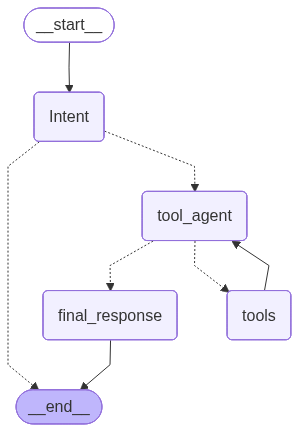

In [11]:
builder = StateGraph(Graph_State)

builder.add_node("Intent",Intent)
builder.add_node("tool_agent",Tool_agent)
builder.add_node("tools",tool_node)
builder.add_node("final_response", Final_Response)  # New node


builder.add_edge(START,"Intent")
builder.add_conditional_edges("Intent",intent_route)
builder.add_conditional_edges("tool_agent",tool_agent_route)
builder.add_edge("tools","tool_agent")
builder.add_edge("final_response", END)
# Removed: builder.add_edge("tool_agent",END) - tools_condition handles routing to END

graph = builder.compile()


display(Image(graph.get_graph(xray=True).draw_mermaid_png()))

# Testing


In [15]:
messages = [HumanMessage(content="ಮುಂದಿನ ವಾರಕ್ಕೆ ನಾನು ಎಷ್ಟು ಪಾರ್ಲೆ-ಜಿ ಸ್ಟಾಕ್ ಮಾಡಬೇಕು?")]
test_chat = graph.invoke({"messages": messages})

for m in test_chat['messages']:
    m.pretty_print()

================================ Human Message =================================

ಮುಂದಿನ ವಾರಕ್ಕೆ ನಾನು ಎಷ್ಟು ಪಾರ್ಲೆ-ಜಿ ಸ್ಟಾಕ್ ಮಾಡಬೇಕು?
================================== Ai Message ==================================

ಮುಂದಿನ ವಾರಕ್ಕೆ ಎಷ್ಟು ಪಾರ್ಲೆ-ಜಿ ಸ್ಟಾಕ್ ಮಾಡಬೇಕು ಎಂದು ಲೆಕ್ಕಾಚಾರ ಮಾಡುತ್ತಿದ್ದೇನೆ...
================================== Ai Message ==================================
Tool Calls:
  trend_search (444f454a-4fcc-4bb2-8f16-e86da1c02f5c)
 Call ID: 444f454a-4fcc-4bb2-8f16-e86da1c02f5c
  Args:
    query: Parle-G demand forecast for next week stocking guidance
================================= Tool Message =================================
Name: trend_search

Here are the latest trends for 'Parle-G demand forecast for next week stocking guidance': [Trend 1, Trend 2, Trend 3]
================================== Ai Message ==================================
Tool Calls:
  demand_forecast_tool (74eeef7a-91be-4c9a-898a-4fc2f8b5a4ef)
 Call ID: 74eeef7a-91be-4c9a-898a-4fc2f8b5a4ef
  Args:
    inp

bool